# 06. Sensor Stream Entropy Case Study

This notebook extends the entropy suite with a **sensor-stream case study** built around realistic synthetic telemetry.

The goal is not only to compute Approximate Entropy (ApEn), but to show how entropy-style features can become part of a broader analytics pipeline for streaming systems.

We will cover:

- realistic sensor-stream simulation with multiple operating regimes,
- missing-data handling and preprocessing,
- a careful from-scratch implementation of ApEn, Sample Entropy, and Permutation Entropy,
- rolling-window feature extraction,
- a regime-classification pipeline using entropy features,
- and a simple change-score mechanism for regime transition detection.

Although the dataset is synthetic, the design is close to real telemetry settings such as:

- IoT devices in smart environments,
- machine health monitoring,
- wearable or physiological streams,
- environmental telemetry,
- or system-performance monitoring.

## 1. Why this notebook matters

A common mistake in telemetry analysis is to look only at:

- the level of the signal,
- its variance,
- or simple thresholds.

These metrics are useful, but they do **not** directly measure temporal regularity.

Two windows can have a similar mean and variance while having very different internal structure:

- a stable oscillatory pattern,
- a noisy irregular regime,
- a degraded drifting sensor,
- or a stuck / dead sensor.

Entropy-based features help distinguish those cases because they operate on the **ordering and persistence of patterns through time**.

In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Iterable, Sequence

import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:

RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)

## 2. Core entropy implementations

The functions below are intentionally implemented from scratch.

This keeps the notebook transparent and makes it easier to adapt the logic for:

- custom distance metrics,
- domain-specific preprocessing,
- approximate rolling pipelines,
- or deployment inside internal analytics systems.

In [3]:

def _validate_1d_series(x: Sequence[float], min_length: int = 5) -> np.ndarray:
    """Validate and return a finite one-dimensional NumPy array.

    Parameters
    ----------
    x:
        Input sequence representing a time series.
    min_length:
        Minimum required number of observations.

    Returns
    -------
    np.ndarray
        One-dimensional array of dtype float.

    Raises
    ------
    ValueError
        If the input is not valid, contains non-finite values, or is too short.
    """
    arr: np.ndarray = np.asarray(x, dtype=float)

    if arr.ndim != 1:
        raise ValueError("Input series must be one-dimensional.")

    if arr.size < min_length:
        raise ValueError(
            f"Input series must contain at least {min_length} observations."
        )

    if not np.all(np.isfinite(arr)):
        raise ValueError("Input series contains NaN or infinite values.")

    return arr


def _embed(x: np.ndarray, m: int) -> np.ndarray:
    """Construct delay-embedding vectors of dimension m."""
    n: int = x.size
    if m <= 0:
        raise ValueError("Embedding dimension m must be positive.")
    if n <= m:
        raise ValueError("Embedding dimension is too large for the series length.")
    return np.array([x[i : i + m] for i in range(n - m + 1)], dtype=float)


def _default_r(x: np.ndarray, r_ratio: float = 0.2) -> float:
    """Return the canonical tolerance r = r_ratio * std(x)."""
    std: float = float(np.std(x, ddof=0))
    if std == 0.0:
        return 1e-12
    return r_ratio * std


def _chebyshev_pairwise_counts(embedded: np.ndarray, r: float) -> np.ndarray:
    """Count how many embedded vectors are within Chebyshev distance r.

    The count includes the self-match, which is standard for Approximate Entropy.
    """
    diff = np.abs(embedded[:, None, :] - embedded[None, :, :])
    max_diff = diff.max(axis=2)
    return np.sum(max_diff <= r, axis=1)


def approximate_entropy(
    x: Sequence[float],
    m: int = 2,
    r: float | None = None,
    r_ratio: float = 0.2,
) -> float:
    """Compute Approximate Entropy (ApEn) for a one-dimensional series.

    ApEn is defined as:

        ApEn(m, r, N) = phi_m(r) - phi_{m+1}(r)

    where phi_m(r) is based on the average log probability that length-m
    templates remain close under tolerance r.

    Parameters
    ----------
    x:
        One-dimensional time series.
    m:
        Embedding dimension.
    r:
        Tolerance threshold. If None, it is computed from `r_ratio * std(x)`.
    r_ratio:
        Ratio used when `r` is not explicitly provided.

    Returns
    -------
    float
        Approximate Entropy value.
    """
    arr = _validate_1d_series(x, min_length=max(6, m + 2))
    tolerance: float = _default_r(arr, r_ratio=r_ratio) if r is None else float(r)

    if tolerance <= 0:
        raise ValueError("Tolerance r must be positive.")

    def _phi(order: int) -> float:
        emb = _embed(arr, order)
        counts = _chebyshev_pairwise_counts(emb, tolerance).astype(float)
        c = counts / emb.shape[0]
        c = np.clip(c, 1e-12, None)
        return float(np.mean(np.log(c)))

    return _phi(m) - _phi(m + 1)


def sample_entropy(
    x: Sequence[float],
    m: int = 2,
    r: float | None = None,
    r_ratio: float = 0.2,
) -> float:
    """Compute Sample Entropy (SampEn) for a one-dimensional series.

    SampEn excludes self-matches and is often viewed as a refinement of ApEn.
    """
    arr = _validate_1d_series(x, min_length=max(6, m + 2))
    tolerance: float = _default_r(arr, r_ratio=r_ratio) if r is None else float(r)

    if tolerance <= 0:
        raise ValueError("Tolerance r must be positive.")

    def _count_matches(order: int) -> float:
        emb = _embed(arr, order)
        n_vec = emb.shape[0]
        total = 0.0

        for i in range(n_vec - 1):
            dist = np.max(np.abs(emb[i + 1 :] - emb[i]), axis=1)
            total += float(np.sum(dist <= tolerance))

        return total

    b = _count_matches(m)
    a = _count_matches(m + 1)

    if b <= 0 or a <= 0:
        return float("nan")

    return float(-np.log(a / b))


def permutation_entropy(
    x: Sequence[float],
    order: int = 3,
    delay: int = 1,
    normalize: bool = True,
) -> float:
    """Compute permutation entropy using ordinal patterns.

    Parameters
    ----------
    x:
        One-dimensional time series.
    order:
        Embedding dimension for ordinal patterns.
    delay:
        Delay between samples inside a pattern.
    normalize:
        Whether to divide by log(order!).

    Returns
    -------
    float
        Permutation entropy, optionally normalized to [0, 1].
    """
    arr = _validate_1d_series(x, min_length=max(7, order * delay + 1))

    if order < 2:
        raise ValueError("Order must be at least 2.")
    if delay < 1:
        raise ValueError("Delay must be at least 1.")

    n_patterns = arr.size - (order - 1) * delay
    patterns: list[tuple[int, ...]] = []

    for i in range(n_patterns):
        window = arr[i : i + order * delay : delay]
        ranks = tuple(np.argsort(window, kind="mergesort"))
        patterns.append(ranks)

    counts = pd.Series(patterns).value_counts(normalize=True).values.astype(float)
    pe = float(-np.sum(counts * np.log(counts)))

    if normalize:
        pe /= math.log(math.factorial(order))

    return pe

## 3. Synthetic telemetry generator

We simulate a multi-sensor stream with five regimes:

1. **stable_low_noise**  
   A calm regime with low variance and high regularity.

2. **periodic_occupied**  
   A structured but richer regime with periodic patterns.

3. **noisy_drift**  
   An irregular regime with local drift and bursts of randomness.

4. **intermittent_missing**  
   A regime where the sensor signal is partially degraded by missingness.

5. **stuck_sensor**  
   A degenerate regime where the signal becomes nearly constant.

This is useful because entropy measures respond differently to:
- periodicity,
- random irregularity,
- data loss,
- and sensor failure.

In [4]:

@dataclass
class RegimeSpec:
    name: str
    length: int


def simulate_sensor_stream(
    regimes: Sequence[RegimeSpec],
    freq: str = "1min",
    seed: int = 42,
) -> pd.DataFrame:
    """Simulate a multi-sensor telemetry stream with labeled regimes.

    The resulting dataset includes:
    - `signal`: primary sensor signal used for entropy analysis,
    - `temperature`: smoother environmental signal,
    - `battery`: slowly decaying sensor battery,
    - `quality_score`: rough proxy for signal quality,
    - `regime`: true operating regime,
    - `t`: integer time index.

    Returns
    -------
    pd.DataFrame
        Time-indexed synthetic telemetry dataset.
    """
    rng = np.random.default_rng(seed)
    total_length = sum(reg.length for reg in regimes)
    index = pd.date_range("2026-01-01", periods=total_length, freq=freq)

    rows: list[pd.DataFrame] = []
    cursor = 0
    battery_level = 100.0

    for reg in regimes:
        n = reg.length
        t = np.arange(n, dtype=float)
        phase = cursor + t

        # Smooth environmental cycle.
        daily_cycle = 0.8 * np.sin(2 * np.pi * phase / 1440.0)
        temperature = 22.0 + daily_cycle + 0.08 * rng.normal(size=n)

        if reg.name == "stable_low_noise":
            signal = 50.0 + 0.5 * np.sin(2 * np.pi * phase / 30.0) + 0.15 * rng.normal(size=n)
            quality = 0.96 + 0.01 * rng.normal(size=n)

        elif reg.name == "periodic_occupied":
            base = 48.0 + 2.2 * np.sin(2 * np.pi * phase / 20.0)
            harmonic = 0.9 * np.sin(2 * np.pi * phase / 7.0 + 0.4)
            signal = base + harmonic + 0.22 * rng.normal(size=n)
            quality = 0.94 + 0.015 * rng.normal(size=n)

        elif reg.name == "noisy_drift":
            drift = np.linspace(0.0, 7.0, n)
            bursts = rng.normal(scale=1.5, size=n)
            bursts[rng.random(n) < 0.85] *= 0.25
            signal = 49.0 + drift + 0.6 * np.sin(2 * np.pi * phase / 17.0) + bursts
            signal += 0.9 * rng.normal(size=n)
            quality = 0.80 + 0.05 * rng.normal(size=n)

        elif reg.name == "intermittent_missing":
            signal = 51.0 + 1.0 * np.sin(2 * np.pi * phase / 18.0) + 0.45 * rng.normal(size=n)
            missing_mask = rng.random(n) < 0.22
            signal = signal.astype(float)
            signal[missing_mask] = np.nan
            quality = 0.72 + 0.10 * rng.normal(size=n)
            quality[missing_mask] -= 0.18

        elif reg.name == "stuck_sensor":
            base_level = 54.0 + 0.05 * rng.normal()
            signal = base_level + 0.015 * rng.normal(size=n)
            quality = 0.58 + 0.04 * rng.normal(size=n)

        else:
            raise ValueError(f"Unknown regime: {reg.name}")

        battery_decay = np.linspace(0.0, 0.12 * n / 60.0, n)
        battery = battery_level - battery_decay + 0.02 * rng.normal(size=n)
        battery_level = float(battery[-1])

        frame = pd.DataFrame(
            {
                "timestamp": index[cursor : cursor + n],
                "t": np.arange(cursor, cursor + n),
                "signal": signal,
                "temperature": temperature,
                "battery": battery,
                "quality_score": np.clip(quality, 0.0, 1.0),
                "regime": reg.name,
            }
        )
        rows.append(frame)
        cursor += n

    data = pd.concat(rows, axis=0, ignore_index=True).set_index("timestamp")
    return data

In [5]:

regimes = [
    RegimeSpec("stable_low_noise", 700),
    RegimeSpec("periodic_occupied", 700),
    RegimeSpec("noisy_drift", 700),
    RegimeSpec("intermittent_missing", 700),
    RegimeSpec("stuck_sensor", 700),
]

df = simulate_sensor_stream(regimes=regimes, freq="1min", seed=RANDOM_SEED)
df.head()

,t,signal,temperature,battery,quality_score,regime
timestamp,,,,,,
2026-01-01 00:00:00,0,50.166945,22.024377,100.005133,0.971825,stable_low_noise
2026-01-01 00:01:00,1,50.067197,21.920292,99.963707,0.956760,stable_low_noise
2026-01-01 00:02:00,2,50.048746,22.067017,99.981718,0.957959,stable_low_noise
2026-01-01 00:03:00,3,50.285349,22.085717,100.009429,0.955083,stable_low_noise
2026-01-01 00:04:00,4,50.528948,21.857879,99.986395,0.954193,stable_low_noise


In [6]:

df["regime"].value_counts()

regime
stable_low_noise        700
periodic_occupied       700
noisy_drift             700
intermittent_missing    700
stuck_sensor            700
Name: count, dtype: int64

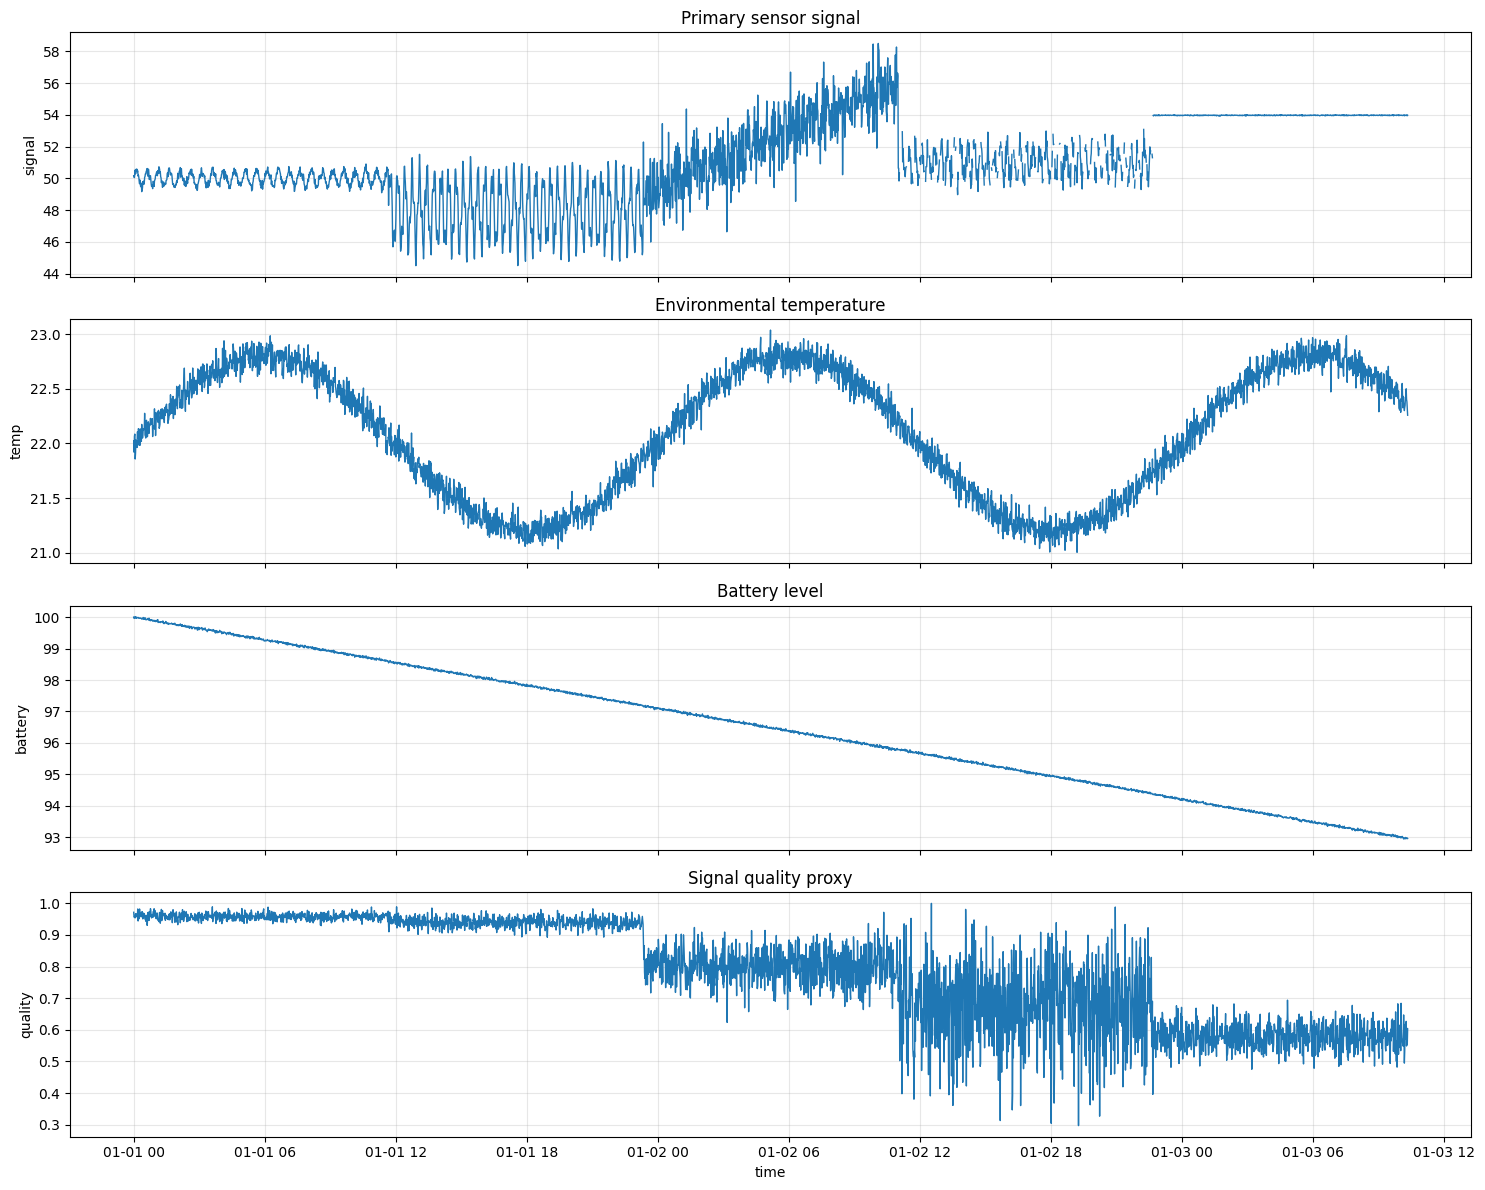

In [7]:

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(df.index, df["signal"], linewidth=1)
axes[0].set_title("Primary sensor signal")
axes[0].set_ylabel("signal")

axes[1].plot(df.index, df["temperature"], linewidth=1)
axes[1].set_title("Environmental temperature")
axes[1].set_ylabel("temp")

axes[2].plot(df.index, df["battery"], linewidth=1)
axes[2].set_title("Battery level")
axes[2].set_ylabel("battery")

axes[3].plot(df.index, df["quality_score"], linewidth=1)
axes[3].set_title("Signal quality proxy")
axes[3].set_ylabel("quality")
axes[3].set_xlabel("time")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The primary signal already shows a useful mix of behaviours:

- smooth regular oscillation,
- structured periodic activity,
- noisy drift,
- explicit missingness,
- and then a near-constant failure mode.

That is exactly the kind of variation where entropy features can add value.

## 4. Preprocessing for entropy features

Entropy functions normally require finite vectors.  
That means rolling analytics must decide what to do with missing values.

There is no universal choice. In practice, common options are:

- forward-fill for short telemetry gaps,
- interpolation for smooth physical sensors,
- model-based reconstruction,
- or dropping windows that are too incomplete.

Below, we use a pragmatic pipeline:

1. linear interpolation,
2. forward/backward fill for edge cases,
3. rolling-window completeness as a separate feature.

This is important because **missingness itself can be informative**.

In [8]:

df["missing_flag"] = df["signal"].isna().astype(int)
df["signal_imputed"] = (
    df["signal"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

df[["signal", "signal_imputed", "missing_flag"]].head(12)

,signal,signal_imputed,missing_flag
timestamp,,,
2026-01-01 00:00:00,50.166945,50.166945,0
2026-01-01 00:01:00,50.067197,50.067197,0
2026-01-01 00:02:00,50.048746,50.048746,0
2026-01-01 00:03:00,50.285349,50.285349,0
2026-01-01 00:04:00,50.528948,50.528948,0
2026-01-01 00:05:00,50.286619,50.286619,0
2026-01-01 00:06:00,50.338942,50.338942,0
2026-01-01 00:07:00,50.581043,50.581043,0
2026-01-01 00:08:00,50.464031,50.464031,0


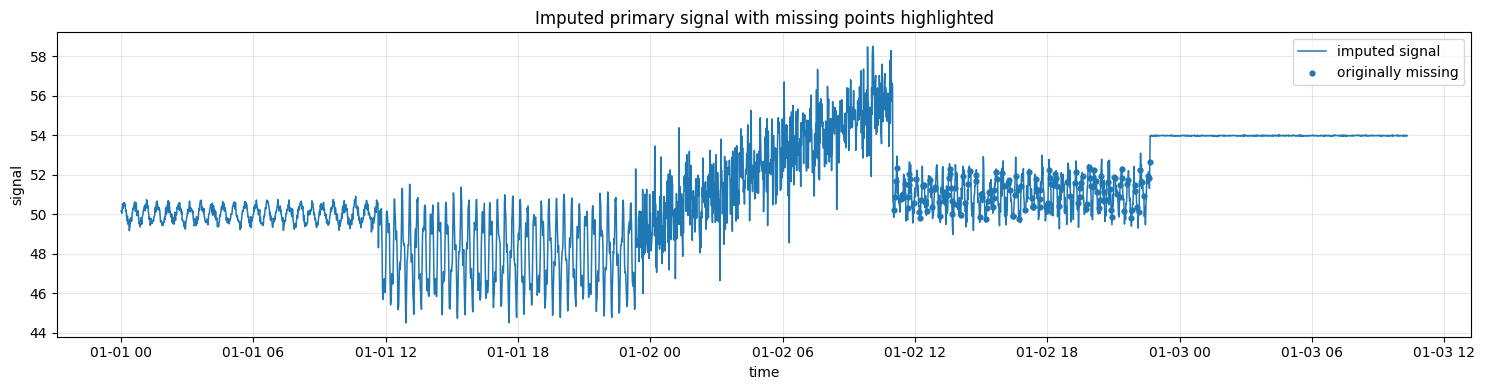

In [9]:

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df["signal_imputed"], label="imputed signal", linewidth=1.1)
ax.scatter(
    df.index[df["missing_flag"] == 1],
    df.loc[df["missing_flag"] == 1, "signal_imputed"],
    s=12,
    label="originally missing",
)
ax.set_title("Imputed primary signal with missing points highlighted")
ax.set_ylabel("signal")
ax.set_xlabel("time")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Why classical moments are not enough

We now compare mean and standard deviation across regimes.  
This is useful, but it is not sufficient.

A periodic regime and an irregular regime can have comparable first and second moments while having very different temporal structure.

In [10]:

summary_by_regime = (
    df.groupby("regime")["signal_imputed"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)
summary_by_regime

,mean,std,min,max
regime,,,,
intermittent_missing,51.023,0.825,48.971,53.082
noisy_drift,52.495,2.390,45.986,58.500
periodic_occupied,47.997,1.699,44.496,51.514
stable_low_noise,50.003,0.380,49.094,50.904
stuck_sensor,53.972,0.015,53.923,54.015


The table above is already informative, but it does not directly answer:

- Is the signal predictable?
- Is it pattern-rich?
- Does it repeat stable local motifs?
- Has the stream become structurally erratic?

That is where entropy enters.

## 6. Rolling entropy feature extraction

We compute features on sliding windows of the imputed primary signal:

- Approximate Entropy,
- Sample Entropy,
- Permutation Entropy,
- mean and standard deviation,
- first-difference volatility,
- missingness fraction,
- and a simple linear trend estimate.

This combination mirrors how entropy would often be used in practice:  
not alone, but as part of a richer feature vector.

In [11]:

def slope_via_least_squares(x: Sequence[float]) -> float:
    """Return the slope of a least-squares line fitted to a one-dimensional series."""
    arr = _validate_1d_series(x, min_length=3)
    t = np.arange(arr.size, dtype=float)
    x_centered = t - t.mean()
    y_centered = arr - arr.mean()
    denom = np.sum(x_centered ** 2)
    if denom == 0:
        return 0.0
    return float(np.sum(x_centered * y_centered) / denom)


def window_majority_label(labels: Sequence[str]) -> str:
    """Return the most frequent label inside a window."""
    return pd.Series(labels).mode().iloc[0]


def rolling_entropy_features(
    frame: pd.DataFrame,
    signal_col: str = "signal_imputed",
    raw_col: str = "signal",
    label_col: str = "regime",
    window: int = 120,
    step: int = 15,
    apen_m: int = 2,
    apen_r_ratio: float = 0.2,
    sampen_m: int = 2,
    sampen_r_ratio: float = 0.2,
    pe_order: int = 4,
) -> pd.DataFrame:
    """Compute rolling-window entropy and summary features.

    Each row corresponds to one window and stores:
    - entropy features,
    - standard summary features,
    - missingness fraction,
    - and the majority regime label.
    """
    if window <= 10:
        raise ValueError("Window must be greater than 10.")
    if step <= 0:
        raise ValueError("Step must be positive.")

    rows: list[dict[str, float | str | pd.Timestamp]] = []

    values = frame[signal_col].to_numpy(dtype=float)
    raw_values = frame[raw_col].to_numpy(dtype=float)
    labels = frame[label_col].to_numpy()
    index = frame.index

    for start in range(0, len(frame) - window + 1, step):
        end = start + window
        xw = values[start:end]
        raw_w = raw_values[start:end]
        label_w = labels[start:end]
        ts_end = index[end - 1]

        diffs = np.diff(xw)
        miss_frac = float(np.mean(~np.isfinite(raw_w)))

        try:
            apen = approximate_entropy(xw, m=apen_m, r_ratio=apen_r_ratio)
        except ValueError:
            apen = float("nan")

        try:
            sampen = sample_entropy(xw, m=sampen_m, r_ratio=sampen_r_ratio)
        except ValueError:
            sampen = float("nan")

        try:
            pent = permutation_entropy(xw, order=pe_order, delay=1, normalize=True)
        except ValueError:
            pent = float("nan")

        rows.append(
            {
                "window_end": ts_end,
                "mean": float(np.mean(xw)),
                "std": float(np.std(xw, ddof=0)),
                "diff_std": float(np.std(diffs, ddof=0)) if diffs.size > 0 else 0.0,
                "slope": slope_via_least_squares(xw),
                "missing_frac": miss_frac,
                "apen": apen,
                "sampen": sampen,
                "perm_entropy": pent,
                "regime": window_majority_label(label_w),
            }
        )

    return pd.DataFrame(rows).set_index("window_end")

In [12]:

features = rolling_entropy_features(
    df,
    signal_col="signal_imputed",
    raw_col="signal",
    label_col="regime",
    window=120,
    step=15,
    apen_m=2,
    apen_r_ratio=0.2,
    sampen_m=2,
    sampen_r_ratio=0.2,
    pe_order=4,
)

features.head()

,mean,std,diff_std,slope,missing_frac,apen,sampen,perm_entropy,regime
window_end,,,,,,,,,
2026-01-01 01:59:00,50.001453,0.384902,0.191726,-0.001788,0.0,0.879161,1.592631,0.938822,stable_low_noise
2026-01-01 02:14:00,49.994752,0.384119,0.207985,0.001794,0.0,0.862866,1.569773,0.934679,stable_low_noise
2026-01-01 02:29:00,50.015979,0.366221,0.210207,-0.002034,0.0,0.789375,1.582409,0.934410,stable_low_noise
2026-01-01 02:44:00,50.013917,0.363104,0.208101,0.001451,0.0,0.746699,1.540445,0.954013,stable_low_noise
2026-01-01 02:59:00,49.998455,0.375164,0.206481,-0.002536,0.0,0.772509,1.577689,0.959526,stable_low_noise


In [13]:

features.groupby("regime")[["mean", "std", "apen", "sampen", "perm_entropy", "missing_frac"]].mean().round(3)

,mean,std,apen,sampen,perm_entropy,missing_frac
regime,,,,,,
intermittent_missing,51.206,0.998,0.712,1.465,0.878,0.204
noisy_drift,52.364,1.373,0.643,2.088,0.969,0.005
periodic_occupied,48.070,1.692,0.727,1.257,0.800,0.000
stable_low_noise,49.962,0.438,0.786,1.526,0.952,0.000
stuck_sensor,53.900,0.126,0.589,2.070,0.973,0.006


Interpretation guide:

- **low ApEn / low SampEn** often indicates more persistent and regular structure,
- **high entropy** often indicates stronger local unpredictability,
- **high permutation entropy** indicates richer variation in ordinal patterns,
- **high missing fraction** warns that the entropy estimate should be interpreted carefully,
- **very low variance with very low entropy** can indicate a stuck sensor rather than healthy regularity.

That last point is important.  
Not every low-entropy regime is desirable.

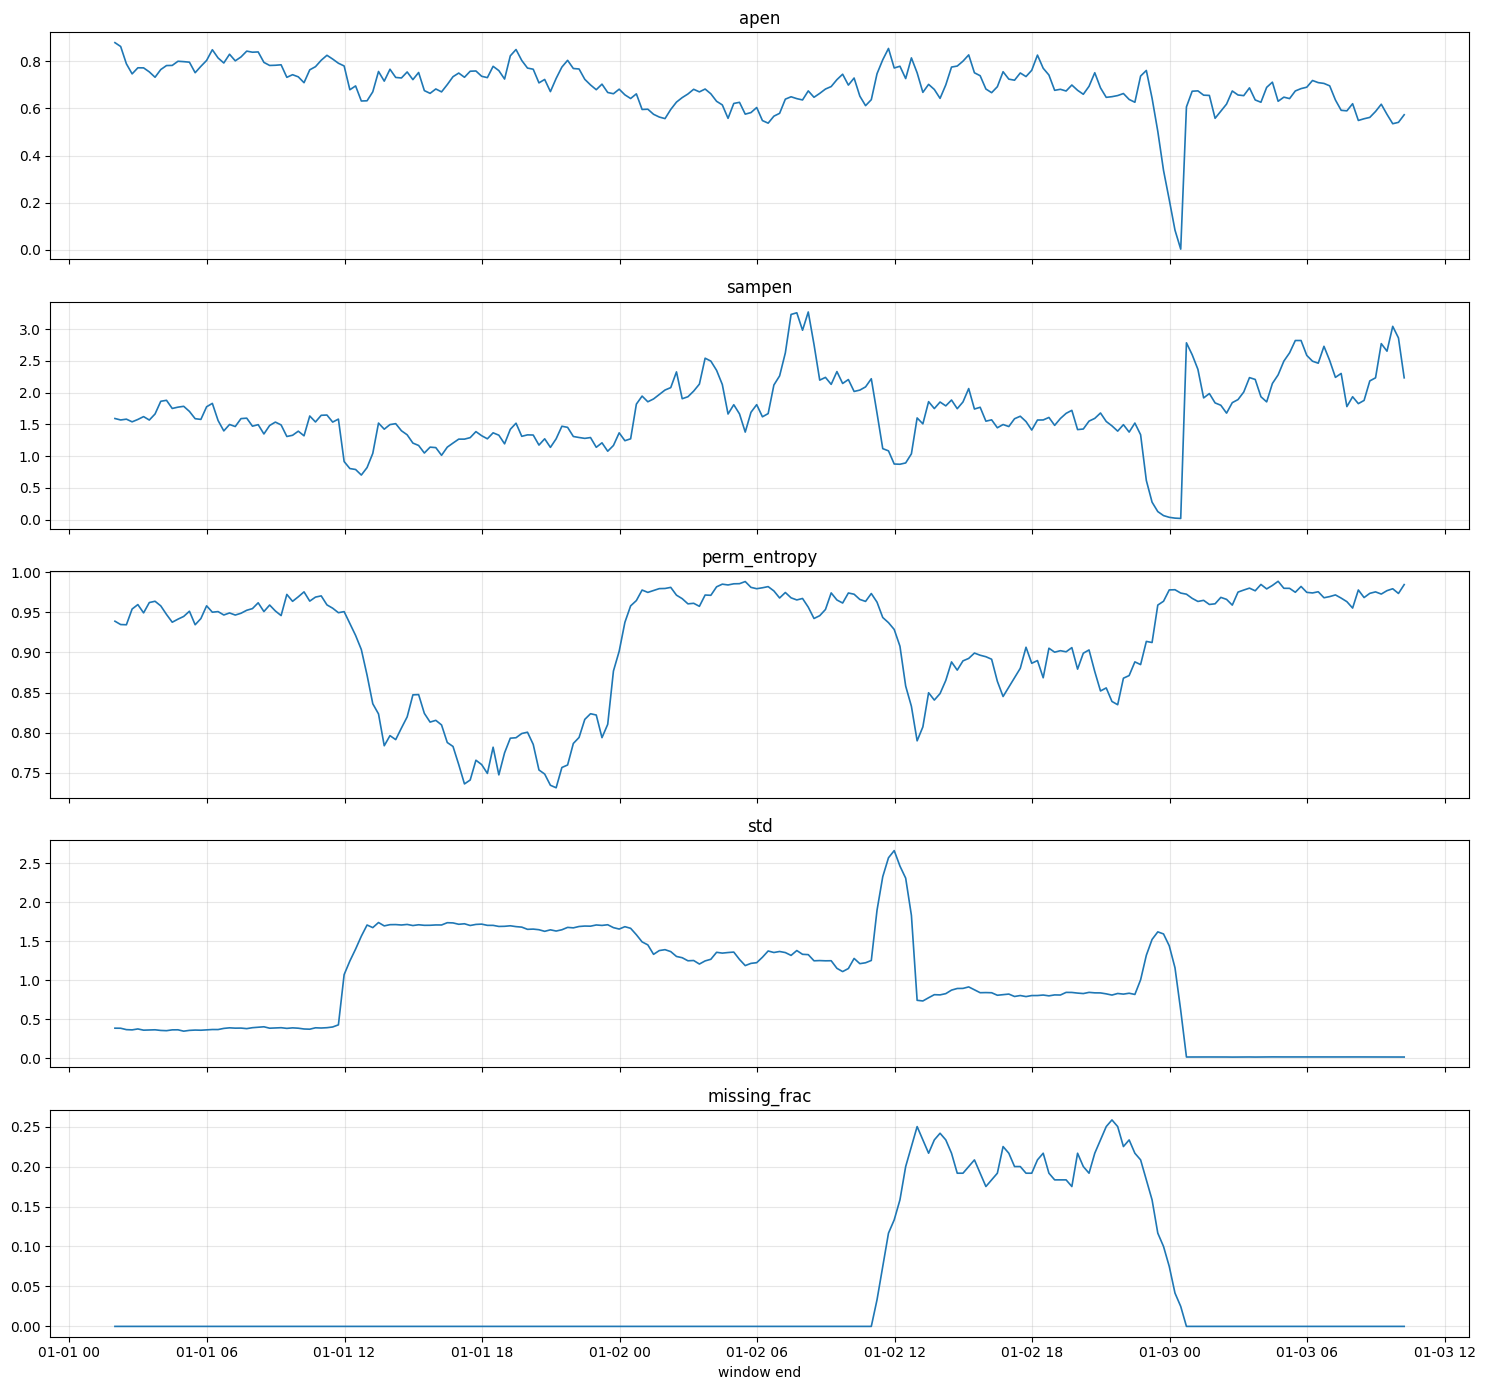

In [14]:

plot_cols = ["apen", "sampen", "perm_entropy", "std", "missing_frac"]
fig, axes = plt.subplots(len(plot_cols), 1, figsize=(15, 14), sharex=True)

for ax, col in zip(axes, plot_cols):
    ax.plot(features.index, features[col], linewidth=1.2)
    ax.set_title(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("window end")
plt.tight_layout()
plt.show()

## 7. Entropy separated by operating regime

A more direct view comes from plotting the entropy features grouped by the true regime.

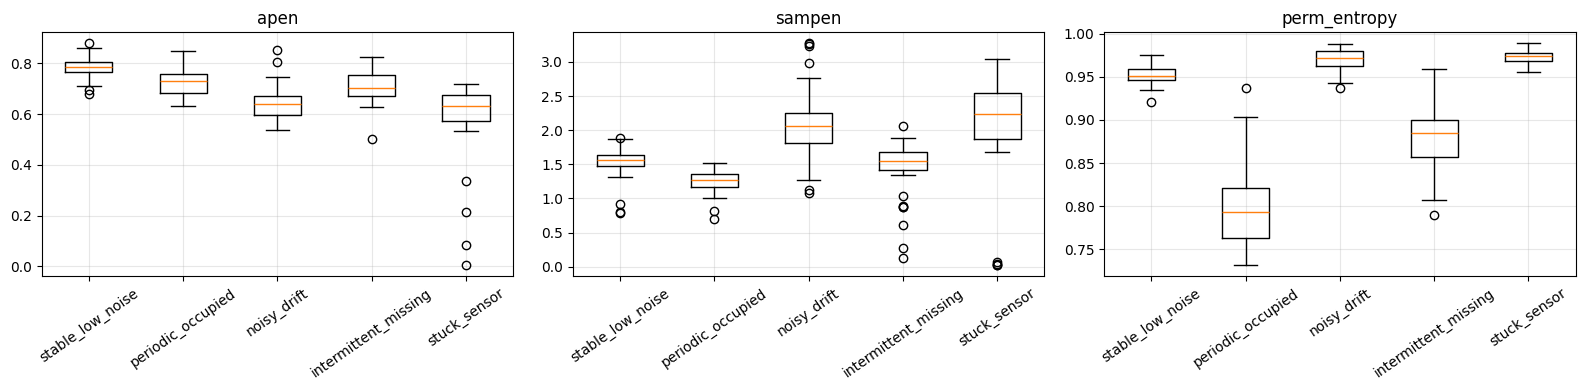

In [15]:

regime_order = [
    "stable_low_noise",
    "periodic_occupied",
    "noisy_drift",
    "intermittent_missing",
    "stuck_sensor",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ["apen", "sampen", "perm_entropy"]):
    grouped = [features.loc[features["regime"] == reg, metric].dropna().values for reg in regime_order]
    ax.boxplot(grouped, tick_labels=regime_order, vert=True)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Typical qualitative pattern in this simulation:

- **stable_low_noise** tends to have low entropy,
- **periodic_occupied** can have moderate entropy because it is structured but richer,
- **noisy_drift** tends to push entropy upward,
- **intermittent_missing** may distort entropy unless missingness is modeled,
- **stuck_sensor** often shows extremely low variance and very low entropy.

This shows why entropy should be interpreted together with standard features such as variance and missingness.

## 8. Building a regime-classification pipeline

Entropy features are often most useful when embedded into a downstream model.

Here we build a simple supervised regime classifier.

### Design choice
We split data by contiguous blocks rather than random rows where possible.  
This reduces leakage because adjacent windows overlap heavily in time.

In [16]:

# Build approximate block groups to reduce leakage from overlapping windows.
features = features.copy()
features["block_id"] = np.arange(len(features)) // 8

feature_cols = [
    "mean",
    "std",
    "diff_std",
    "slope",
    "missing_frac",
    "apen",
    "sampen",
    "perm_entropy",
]

X = features[feature_cols]
y = features["regime"]
groups = features["block_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

intermittent_missing       0.93      0.93      0.93        15
         noisy_drift       1.00      0.94      0.97        16
   periodic_occupied       1.00      1.00      1.00        16
    stable_low_noise       1.00      1.00      1.00         8
        stuck_sensor       0.94      1.00      0.97        17

            accuracy                           0.97        72
           macro avg       0.98      0.97      0.97        72
        weighted avg       0.97      0.97      0.97        72



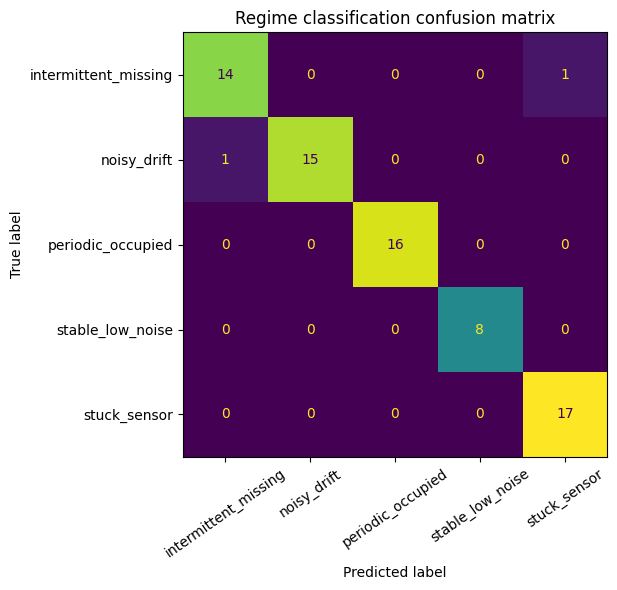

In [17]:

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    xticks_rotation=35,
    colorbar=False,
)
ax.set_title("Regime classification confusion matrix")
plt.tight_layout()
plt.show()

In [18]:

rf = model.named_steps["clf"]
importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "importance": rf.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df

,feature,importance
0,diff_std,0.224284
1,mean,0.183337
2,std,0.155081
3,perm_entropy,0.127923
4,missing_frac,0.124860
5,apen,0.070489
6,slope,0.068360
7,sampen,0.045666


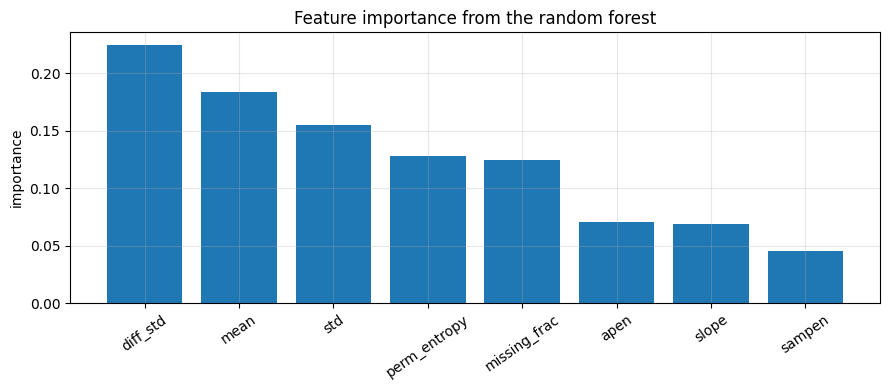

In [19]:

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(importance_df["feature"], importance_df["importance"])
ax.set_title("Feature importance from the random forest")
ax.set_ylabel("importance")
ax.tick_params(axis="x", rotation=35)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This stage is important from a data-science perspective.

We are no longer treating entropy as an isolated academic statistic.  
We are treating it as a **feature family** that can participate in a prediction system.

In many telemetry applications, that is the most practical role for entropy.

## 9. Change-score mechanism for regime transitions

A simple unsupervised-style monitoring idea is to track the change in entropy features from one window to the next.

Large shifts can indicate:
- a new operating regime,
- onset of sensor degradation,
- or a behavioral transition in the underlying system.

In [20]:

change_df = features[["apen", "sampen", "perm_entropy", "std", "missing_frac"]].copy()

# Standardize columns manually for a simple Euclidean change score.
change_z = (change_df - change_df.mean()) / change_df.std(ddof=0)
change_z = change_z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

change_score = np.sqrt(np.sum(np.diff(change_z.values, axis=0) ** 2, axis=1))
change_index = features.index[1:]

change_series = pd.Series(change_score, index=change_index, name="change_score")
threshold = float(change_series.quantile(0.95))
alerts = change_series[change_series >= threshold]

threshold, alerts.head()

(1.2177171071281163,
 window_end
 2026-01-01 11:59:00    1.557516
 2026-01-02 11:14:00    1.783051
 2026-01-02 11:29:00    1.434969
 2026-01-02 12:44:00    1.223782
 2026-01-02 12:59:00    2.154286
 Name: change_score, dtype: float64)

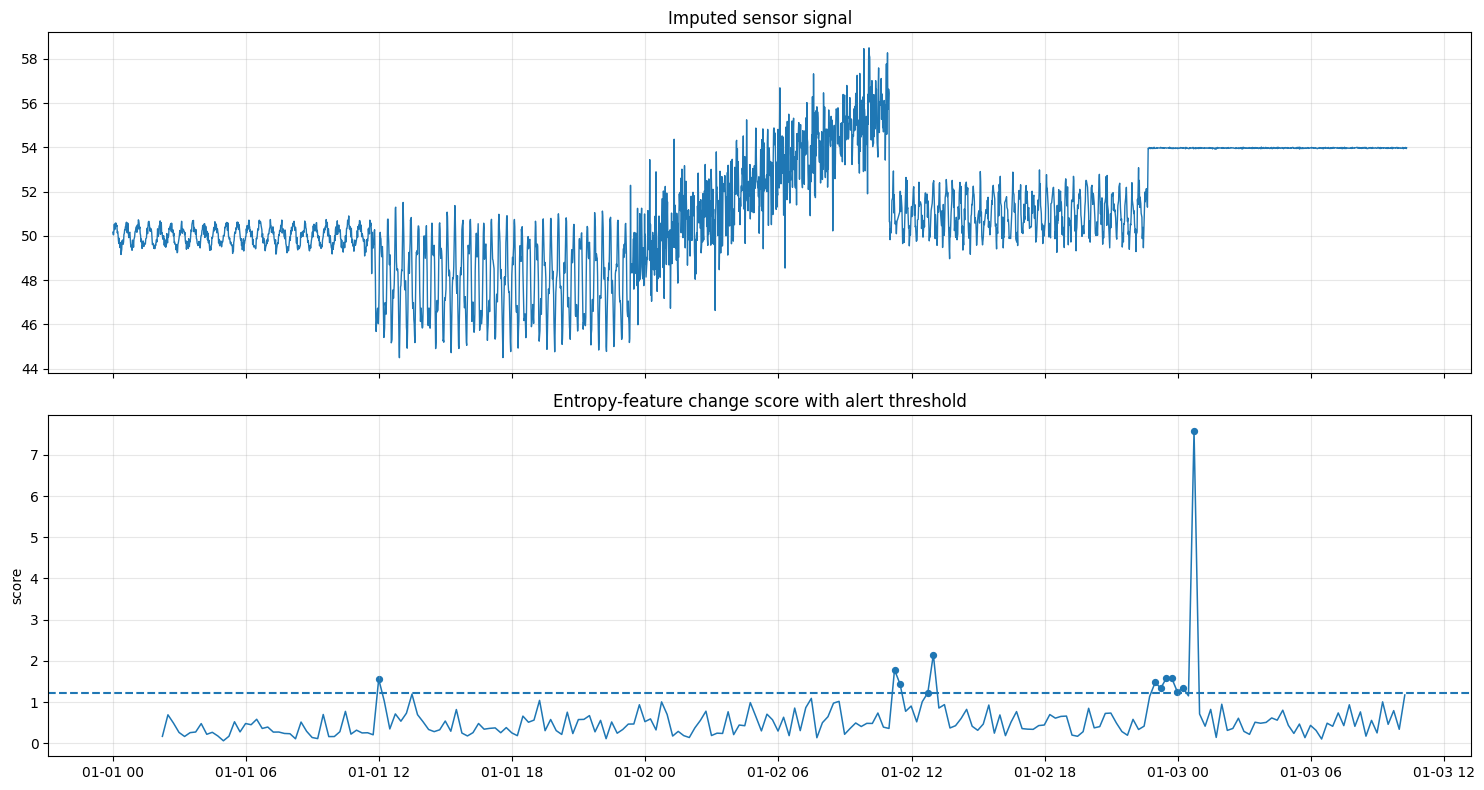

In [21]:

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df.index, df["signal_imputed"], linewidth=1.0)
axes[0].set_title("Imputed sensor signal")
axes[0].grid(alpha=0.3)

axes[1].plot(change_series.index, change_series.values, linewidth=1.1)
axes[1].axhline(threshold, linestyle="--")
axes[1].scatter(alerts.index, alerts.values, s=18)
axes[1].set_title("Entropy-feature change score with alert threshold")
axes[1].set_ylabel("score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The change-score is intentionally simple.  
In production, it could be replaced by:

- CUSUM or Page-Hinkley style detectors,
- Bayesian online change-point methods,
- streaming drift detectors,
- one-class anomaly models,
- or domain-specific state machines.

The main idea remains the same:  
**rolling entropy features are often more informative than raw values alone.**

## 10. A compact sklearn-style transformer

To make the workflow reusable, we wrap the feature extraction logic in a small transformer.

This is useful if you want to integrate entropy features into a larger modeling pipeline.

In [22]:

class RollingEntropyFeatureExtractor(BaseEstimator, TransformerMixin):
    """Sklearn-style transformer for fixed-window entropy features.

    Notes
    -----
    This transformer expects a pandas DataFrame with at least:
    - a signal column,
    - a raw signal column,
    - and optionally a label column.

    It returns a DataFrame of rolling-window features.
    """

    def __init__(
        self,
        signal_col: str = "signal_imputed",
        raw_col: str = "signal",
        label_col: str = "regime",
        window: int = 120,
        step: int = 15,
        apen_m: int = 2,
        apen_r_ratio: float = 0.2,
        sampen_m: int = 2,
        sampen_r_ratio: float = 0.2,
        pe_order: int = 4,
    ) -> None:
        self.signal_col = signal_col
        self.raw_col = raw_col
        self.label_col = label_col
        self.window = window
        self.step = step
        self.apen_m = apen_m
        self.apen_r_ratio = apen_r_ratio
        self.sampen_m = sampen_m
        self.sampen_r_ratio = sampen_r_ratio
        self.pe_order = pe_order

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "RollingEntropyFeatureExtractor":
        """No-op fit for sklearn compatibility."""
        if not isinstance(X, pd.DataFrame):
            raise TypeError("X must be a pandas DataFrame.")
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """Compute rolling entropy features from a DataFrame."""
        if not isinstance(X, pd.DataFrame):
            raise TypeError("X must be a pandas DataFrame.")

        return rolling_entropy_features(
            frame=X,
            signal_col=self.signal_col,
            raw_col=self.raw_col,
            label_col=self.label_col,
            window=self.window,
            step=self.step,
            apen_m=self.apen_m,
            apen_r_ratio=self.apen_r_ratio,
            sampen_m=self.sampen_m,
            sampen_r_ratio=self.sampen_r_ratio,
            pe_order=self.pe_order,
        )

In [23]:

extractor = RollingEntropyFeatureExtractor(window=120, step=30)
feature_view = extractor.fit_transform(df)
feature_view.head()

,mean,std,diff_std,slope,missing_frac,apen,sampen,perm_entropy,regime
window_end,,,,,,,,,
2026-01-01 01:59:00,50.001453,0.384902,0.191726,-0.001788,0.0,0.879161,1.592631,0.938822,stable_low_noise
2026-01-01 02:29:00,50.015979,0.366221,0.210207,-0.002034,0.0,0.789375,1.582409,0.934410,stable_low_noise
2026-01-01 02:59:00,49.998455,0.375164,0.206481,-0.002536,0.0,0.772509,1.577689,0.959526,stable_low_noise
2026-01-01 03:29:00,49.980693,0.362211,0.214275,-0.002312,0.0,0.755119,1.568616,0.962065,stable_low_noise
2026-01-01 03:59:00,49.993972,0.355912,0.220190,-0.001619,0.0,0.765121,1.864080,0.957902,stable_low_noise


## 11. Practical lessons

This notebook suggests a few important practical conclusions.

### 11.1 Entropy is not a replacement for standard features
It is best used together with:
- variability,
- trend,
- missingness,
- domain features,
- and quality indicators.

### 11.2 Low entropy can mean two very different things
It can indicate:
- healthy regularity,
- or sensor failure / saturation / stuck behavior.

That is why variance and quality proxies are essential.

### 11.3 Missing data needs explicit handling
Entropy estimates can become unstable or misleading if missing windows are treated carelessly.

### 11.4 Rolling entropy is especially useful for regime analysis
This is where entropy becomes operational:
- regime recognition,
- transition detection,
- anomaly monitoring,
- or drift-aware modeling.

## 12. Suggested real-world adaptations

To adapt this notebook to a real project, a good path would be:

1. replace the synthetic generator with your telemetry source,
2. add domain-aware preprocessing,
3. choose window sizes based on system dynamics,
4. calibrate `m` and `r` carefully,
5. validate features against known incidents or labels,
6. and compare against simpler baselines.

Good benchmark questions include:

- Does entropy improve early detection?
- Does it distinguish healthy periodicity from chaotic behavior?
- Does it help detect sensor degradation before thresholds are crossed?
- Does it add predictive value beyond mean, std, and trend?

## 13. Final takeaway

Approximate Entropy is most valuable when treated as a **structural feature of time-series behaviour**, not merely as a standalone statistic.

In sensor analytics, it helps answer questions that moments cannot answer directly:

- Is the stream becoming less regular?
- Is the process drifting into disorder?
- Is the sensor healthy but periodic, or simply stuck?
- Is the system transitioning into another regime?

That is the main reason entropy features are useful in modern telemetry and streaming analysis pipelines.